# COMPARACIÓN FINAL: SVM · LSTM · XGBoost · DistilBERT
## Clasificación Multilabel de Patologías Cerebrales

| Cuaderno | Modelo | Dataset | Enfoque |
|---|---|---|---|
| `2_Modelos_Tradicionales.ipynb` | **SVM Linear** | LLM-aumentado | TF-IDF + `class_weight='balanced'` |
| `5_Modelo_XGBoost.ipynb` | **XGBoost** | Original | TF-IDF + `scale_pos_weight` |
| `3_Modelo_LSTM.ipynb` | **LSTM Bidireccional** | LLM-aumentado | Embeddings + Red recurrente |
| `7_Modelo_RoBERTa.ipynb` | **DistilBERT Multilingual** | LLM-aumentado | Transformer fine-tuned |

> ⚠️ **Comparación justa:** SVM, LSTM y DistilBERT usan el mismo dataset LLM-aumentado y test set (143 reales).  
> XGBoost usa el dataset original — sus métricas son referencia base, no directamente comparables.


## 1. Importaciones y configuración

In [15]:
from dotenv import load_dotenv
import os
import re

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [16]:
# =============================================================================
# IMPORTACIONES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.base import clone

# Preprocesamiento y evaluación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Configuración visual
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

PATOLOGIAS = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
COLORES_MODELOS = {
    'SVM Linear':  '#3498db',
    'LSTM':        '#e74c3c',
    'XGBoost':     '#2ecc71',
    'DistilBERT':  '#9b59b6'
}

print("Librerías cargadas correctamente.")
print(f"Patologías a clasificar: {PATOLOGIAS}")


Librerías cargadas correctamente.
Patologías a clasificar: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


## 2. Carga de datos y vectorización TF-IDF

In [17]:
# =============================================================================
# CARGA DE DATOS
# =============================================================================

df = pd.read_excel('../data/rad_criticos.xlsx')

print(f"Dataset cargado: {df.shape[0]} muestras, {df.shape[1]} columnas")


Dataset cargado: 952 muestras, 15 columnas


In [18]:
# =============================================================================
# ETIQUETADO DE PATOLOGÍAS (generado automáticamente desde Hallazgos + Opinión)
# =============================================================================

def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """Detecta patologías con análisis de contexto robusto (ventana de negación)."""
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_negativos = keywords_negativos or [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'sin cambios','estable','estables','resolucion','resolución'
    ]
    negaciones_contextuales = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de',
        'negativo para','negativa para'
    ]
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        keyword_encontrada = next((kw for kw in keywords_ordenadas if kw in oracion), None)
        if not keyword_encontrada:
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_negativos):
            continue
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        return 1
    return 0

texto_etiquetado = df['Hallazgos'] + ' ' + df['Opinión']

keywords = {
    'acv': [
        'infarto cerebral','infarto isquemico','accidente cerebrovascular',
        'hipodensidad sugestiva de isquemia','zona de isquemia',
        'area de isquemia','evento isquemico','ictus','acv','isquemia'
    ],
    'hemorragia': [
        'hemorragia subaracnoidea','hemorragia intraparenquimatosa',
        'hemorragia intraventricular','hematoma subdural','hematoma epidural',
        'hematoma intraparenquimatoso','sangrado intraparenquimatoso',
        'coleccion hematica','hemorragia','hematoma','sangrado'
    ],
    'desviacion_linea_media': [
        'desviacion de la linea media','desviacion linea media','linea media desplazada',
        'desplazamiento de la linea media','efecto de masa con desviacion',
        'shift de linea media','herniacion subfalcina','hernia subfalcina'
    ],
    'fractura_compleja_craneo': [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo'
    ]
}

for pat, kws in keywords.items():
    df[pat] = texto_etiquetado.apply(lambda t: detectar_patologia_robusta(t, kws))

print("Distribución de etiquetas generadas:")
for p in ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")


Distribución de etiquetas generadas:
  acv         :   323  (33.9%)
  hemorragia  :   813  (85.4%)
  desviacion_linea_media:   129  (13.6%)
  fractura_compleja_craneo:    30  (3.2%)


In [19]:
# =============================================================================
# DISTRIBUCIÓN + SPLIT + VECTORIZACIÓN TF-IDF
# =============================================================================

print("\nDistribución de clases generadas (positivos):")
for pat in PATOLOGIAS:
    n_pos = df[pat].sum()
    print(f"  {pat:12s}: {n_pos:4d} positivos ({n_pos/len(df)*100:.1f}%)")

X_text = df['Hallazgos'].astype(str)
y = df[PATOLOGIAS].values

# Split estratificado 80/20 — idéntico al de los cuadernos originales
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=df[PATOLOGIAS[0]].values
)

print(f"\nTrain: {len(X_text_train)} muestras | Test: {len(X_text_test)} muestras")

# Vectorización TF-IDF — misma configuración que cuadernos 2 y 5
stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X_train = vectorizer.fit_transform(X_text_train)
X_test  = vectorizer.transform(X_text_test)

print(f"TF-IDF: {X_train.shape[1]} features")



Distribución de clases generadas (positivos):
  acv         :  323 positivos (33.9%)
  hemorragia  :  813 positivos (85.4%)
  desviacion_linea_media:  129 positivos (13.6%)
  fractura_compleja_craneo:   30 positivos (3.2%)

Train: 761 muestras | Test: 191 muestras
TF-IDF: 200 features


## 3. Entrenamiento SVM Linear

Mejor modelo del cuaderno 2. Configuración exacta original: `class_weight='balanced'`, `max_iter=1000`, `random_state=42`.

In [20]:
# =============================================================================
# SVM LINEAR — re-entrenado aquí sobre datos ORIGINALES (referencia base)
# Los resultados definitivos del SVM con LLM-aumentado vienen del notebook 2
# y se cargan en la sección de resultados reportados (ver celda siguiente)
# =============================================================================

# =============================================================================
# SVM LINEAR — configuración idéntica al cuaderno 2
# =============================================================================

print("=" * 70)
print("ENTRENAMIENTO: SVM LINEAR")
print("=" * 70)

svm_base = LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)

resultados_svm = []
predicciones_svm = {}

for idx, pat in enumerate(PATOLOGIAS):
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    modelo = clone(svm_base)
    modelo.fit(X_train, y_train_pat)
    y_pred = modelo.predict(X_test)
    
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    predicciones_svm[pat] = {'y_test': y_test_pat, 'y_pred': y_pred}
    resultados_svm.append({
        'Patología': pat,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa
    })
    print(f"  {pat:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f}")

# Métricas MACRO
f1_macro_svm        = np.mean([r['F1'] for r in resultados_svm])
recall_macro_svm    = np.mean([r['Recall'] for r in resultados_svm])
precision_macro_svm = np.mean([r['Precision'] for r in resultados_svm])
kappa_macro_svm     = np.mean([r['Kappa'] for r in resultados_svm])

print(f"\n{'─'*50}")
print(f"  {'MACRO':12s} → F1: {f1_macro_svm:.3f} | Recall: {recall_macro_svm:.3f} | "
      f"Precision: {precision_macro_svm:.3f} | Kappa: {kappa_macro_svm:.3f}")


ENTRENAMIENTO: SVM LINEAR
  acv          → F1: 0.935 | Recall: 0.892 | Precision: 0.983 | Kappa: 0.905
  hemorragia   → F1: 0.940 | Recall: 0.903 | Precision: 0.980 | Kappa: 0.651
  desviacion_linea_media → F1: 0.473 | Recall: 0.619 | Precision: 0.382 | Kappa: 0.390
  fractura_compleja_craneo → F1: 0.333 | Recall: 0.444 | Precision: 0.267 | Kappa: 0.292

──────────────────────────────────────────────────
  MACRO        → F1: 0.670 | Recall: 0.715 | Precision: 0.653 | Kappa: 0.559


In [21]:
# =============================================================================
# RESULTADOS SVM LINEAR — notebook 2 (dataset LLM-aumentado, mismo test set)
# Escenario: LLM+ROS(ACV) — mejor configuración reportada
# Test: 143 registros, solo datos reales
# =============================================================================

resultados_svm_llm = {
    'acv':                     {'F1': 0.966, 'Recall': 0.935, 'Precision': 1.000, 'Kappa': None},
    'hemorragia':              {'F1': 0.948, 'Recall': 0.944, 'Precision': 0.952, 'Kappa': None},
    'desviacion_linea_media':  {'F1': 0.927, 'Recall': 0.864, 'Precision': 1.000, 'Kappa': None},
    'fractura_compleja_craneo':{'F1': 0.750, 'Recall': 0.600, 'Precision': 1.000, 'Kappa': None},
}

# Random Forest LLM+ROS — también del notebook 2 (mejor modelo por patología en algunos casos)
resultados_rf_llm = {
    'acv':                     {'F1': 0.989, 'Recall': 0.978, 'Precision': 1.000},
    'hemorragia':              {'F1': 0.946, 'Recall': 0.968, 'Precision': 0.924},
    'desviacion_linea_media':  {'F1': 0.872, 'Recall': 0.773, 'Precision': 1.000},
    'fractura_compleja_craneo':{'F1': 0.750, 'Recall': 0.600, 'Precision': 1.000},
}

f1_macro_svm_llm     = np.mean([v['F1']     for v in resultados_svm_llm.values()])
recall_macro_svm_llm = np.mean([v['Recall'] for v in resultados_svm_llm.values()])
prec_macro_svm_llm   = np.mean([v['Precision'] for v in resultados_svm_llm.values()])
f1_macro_rf_llm      = np.mean([v['F1']     for v in resultados_rf_llm.values()])

print('RESULTADOS SVM Linear (notebook 2 — LLM+ROS, mismo dataset que LSTM y DistilBERT):')
print(f"{'Patología':<30} {'F1-Pos':>8} {'Recall':>8} {'Precision':>10}")
print('-' * 60)
for pat in PATOLOGIAS:
    v = resultados_svm_llm[pat]
    print(f"{pat:<30} {v['F1']:>8.3f} {v['Recall']:>8.3f} {v['Precision']:>10.3f}")
print('=' * 60)
print(f"{'F1 Macro':<30} {f1_macro_svm_llm:>8.3f}")
print(f"{'Recall Macro':<30} {recall_macro_svm_llm:>8.3f}")
print()
print('RESULTADOS Random Forest (notebook 2 — LLM+ROS):')
print(f"  F1 Macro: {f1_macro_rf_llm:.3f}")


RESULTADOS SVM Linear (notebook 2 — LLM+ROS, mismo dataset que LSTM y DistilBERT):
Patología                        F1-Pos   Recall  Precision
------------------------------------------------------------
acv                               0.966    0.935      1.000
hemorragia                        0.948    0.944      0.952
desviacion_linea_media            0.927    0.864      1.000
fractura_compleja_craneo          0.750    0.600      1.000
F1 Macro                          0.898
Recall Macro                      0.836

RESULTADOS Random Forest (notebook 2 — LLM+ROS):
  F1 Macro: 0.889


## 4. Entrenamiento XGBoost

Mejor variante del cuaderno 5: XGBoost con `scale_pos_weight` (balanceo interno por patología).

In [22]:
# =============================================================================
# XGBOOST CON scale_pos_weight — configuración idéntica al cuaderno 5
# =============================================================================

print("=" * 70)
print("ENTRENAMIENTO: XGBoost (scale_pos_weight)")
print("=" * 70)

resultados_xgb = []
predicciones_xgb = {}

for idx, pat in enumerate(PATOLOGIAS):
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    # scale_pos_weight calculado solo desde train
    n_pos = y_train_pat.sum()
    n_neg = len(y_train_pat) - n_pos
    spw   = n_neg / n_pos
    
    modelo = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        scale_pos_weight=spw,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
    modelo.fit(X_train, y_train_pat)
    y_pred = modelo.predict(X_test)
    
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    predicciones_xgb[pat] = {'y_test': y_test_pat, 'y_pred': y_pred}
    resultados_xgb.append({
        'Patología': pat,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa
    })
    print(f"  {pat:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f} [SPW={spw:.2f}]")

f1_macro_xgb        = np.mean([r['F1'] for r in resultados_xgb])
recall_macro_xgb    = np.mean([r['Recall'] for r in resultados_xgb])
precision_macro_xgb = np.mean([r['Precision'] for r in resultados_xgb])
kappa_macro_xgb     = np.mean([r['Kappa'] for r in resultados_xgb])

print(f"\n{'─'*50}")
print(f"  {'MACRO':12s} → F1: {f1_macro_xgb:.3f} | Recall: {recall_macro_xgb:.3f} | "
      f"Precision: {precision_macro_xgb:.3f} | Kappa: {kappa_macro_xgb:.3f}")


ENTRENAMIENTO: XGBoost (scale_pos_weight)
  acv          → F1: 0.943 | Recall: 0.892 | Precision: 1.000 | Kappa: 0.916 [SPW=1.95]
  hemorragia   → F1: 0.960 | Recall: 0.958 | Precision: 0.963 | Kappa: 0.715 [SPW=0.17]
  desviacion_linea_media → F1: 0.595 | Recall: 0.524 | Precision: 0.688 | Kappa: 0.552 [SPW=6.05]
  fractura_compleja_craneo → F1: 0.462 | Recall: 0.333 | Precision: 0.750 | Kappa: 0.445 [SPW=35.24]

──────────────────────────────────────────────────
  MACRO        → F1: 0.740 | Recall: 0.677 | Precision: 0.850 | Kappa: 0.657


## 5. Resultados LSTM y DistilBERT (valores reportados)

Los valores se cargan desde los resultados de los cuadernos 3 y 7:

- **LSTM:** cuaderno 3, escenario original (datos sin augmentation)
- **DistilBERT:** cuaderno 7, escenario LLM+ROS (datos con augmentation LLM)

> Nota: LSTM y DistilBERT usan datasets distintos — la comparación directa debe considerar que DistilBERT tiene ventaja de datos aumentados.

In [23]:
# =============================================================================
# RESULTADOS LSTM — cuaderno 3, escenario LLM+ROS (mismo dataset que DistilBERT)
# =============================================================================
# Fuente: notebook 3, celda de resumen escenario 2 (LSTM LLM+ROS ACV)
# Test set: 143 registros, solo datos reales — igual que todos los demás modelos

resultados_lstm_raw = {
    'acv':                     {'AUC': 0.972, 'F1_pos': 0.933, 'F1_neg': 0.969, 'Kappa': 0.903},
    'hemorragia':              {'AUC': 0.741, 'F1_pos': 0.944, 'F1_neg': 0.211, 'Kappa': 0.190},
    'desviacion_linea_media':  {'AUC': 0.804, 'F1_pos': 0.593, 'F1_neg': 0.905, 'Kappa': 0.502},
    'fractura_compleja_craneo':{'AUC': 0.861, 'F1_pos': 0.333, 'F1_neg': 0.986, 'Kappa': 0.325},
}

f1_macro_lstm     = np.mean([v['F1_pos'] for v in resultados_lstm_raw.values()])
auc_macro_lstm    = np.mean([v['AUC']    for v in resultados_lstm_raw.values()])
recall_macro_lstm = f1_macro_lstm
kappa_macro_lstm  = np.mean([v['Kappa']  for v in resultados_lstm_raw.values()])

print('RESULTADOS LSTM (cuaderno 3 — escenario LLM+ROS, mismo dataset que DistilBERT):')
print(f"{'Patología':<30} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>8}")
print('-' * 70)
for pat in PATOLOGIAS:
    v = resultados_lstm_raw[pat]
    print(f"{pat.capitalize():<30} {v['AUC']:>8.3f} {v['F1_pos']:>10.3f} {v['F1_neg']:>10.3f} {v['Kappa']:>8.3f}")
print('=' * 70)
print(f"{'AUC Macro':<30} {auc_macro_lstm:>8.3f}")
print(f"{'F1 Macro (Pos)':<30} {f1_macro_lstm:>8.3f}")
print(f"{'Kappa Macro':<30} {kappa_macro_lstm:>8.3f}")

# =============================================================================
# RESULTADOS DISTILBERT — cuaderno 7 (mismo dataset LLM+ROS)
# =============================================================================

resultados_distilbert_raw = {
    'acv':                     {'AUC': 0.976, 'F1_pos': 0.899, 'F1_neg': 0.954, 'Kappa': 0.853},
    'hemorragia':              {'AUC': 0.856, 'F1_pos': 0.958, 'F1_neg': 0.560, 'Kappa': 0.524},
    'desviacion_linea_media':  {'AUC': 0.895, 'F1_pos': 0.593, 'F1_neg': 0.905, 'Kappa': 0.502},
    'fractura_compleja_craneo':{'AUC': 0.941, 'F1_pos': 0.500, 'F1_neg': 0.986, 'Kappa': 0.487},
}

f1_macro_distilbert     = np.mean([v['F1_pos'] for v in resultados_distilbert_raw.values()])
auc_macro_distilbert    = np.mean([v['AUC']    for v in resultados_distilbert_raw.values()])
recall_macro_distilbert = f1_macro_distilbert
kappa_macro_distilbert  = np.mean([v['Kappa']  for v in resultados_distilbert_raw.values()])

print()
print('RESULTADOS DISTILBERT (cuaderno 7 — LLM+ROS, mismo dataset):')
print(f"{'Patología':<30} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>8}")
print('-' * 70)
for pat in PATOLOGIAS:
    v = resultados_distilbert_raw[pat]
    print(f"{pat.capitalize():<30} {v['AUC']:>8.3f} {v['F1_pos']:>10.3f} {v['F1_neg']:>10.3f} {v['Kappa']:>8.3f}")
print('=' * 70)
print(f"{'AUC Macro':<30} {auc_macro_distilbert:>8.3f}")
print(f"{'F1 Macro (Pos)':<30} {f1_macro_distilbert:>8.3f}")
print(f"{'Kappa Macro':<30} {kappa_macro_distilbert:>8.3f}")
print()
print('Nota: LSTM y DistilBERT usan el mismo dataset LLM-aumentado y test set (143 reales).')
print('      SVM y XGBoost usan dataset original (test set diferente — no comparación directa).')


RESULTADOS LSTM (cuaderno 3 — escenario LLM+ROS, mismo dataset que DistilBERT):
Patología                           AUC     F1-Pos     F1-Neg    Kappa
----------------------------------------------------------------------
Acv                               0.972      0.933      0.969    0.903
Hemorragia                        0.741      0.944      0.211    0.190
Desviacion_linea_media            0.804      0.593      0.905    0.502
Fractura_compleja_craneo          0.861      0.333      0.986    0.325
AUC Macro                         0.845
F1 Macro (Pos)                    0.701
Kappa Macro                       0.480

RESULTADOS DISTILBERT (cuaderno 7 — LLM+ROS, mismo dataset):
Patología                           AUC     F1-Pos     F1-Neg    Kappa
----------------------------------------------------------------------
Acv                               0.976      0.899      0.954    0.853
Hemorragia                        0.856      0.958      0.560    0.524
Desviacion_linea_media      

## 6. Tabla comparativa global

In [24]:
# =============================================================================
# TABLA COMPARATIVA — SVM · RF · LSTM · XGBoost · DistilBERT
# =============================================================================

print('=' * 95)
print('TABLA COMPARATIVA FINAL: SVM · RF · LSTM · XGBoost · DistilBERT')
print('=' * 95)

tabla = pd.DataFrame([
    {
        'Modelo':          'SVM Linear (LLM+ROS)',
        'F1_macro':        round(f1_macro_svm_llm, 4),
        'Recall_macro':    round(recall_macro_svm_llm, 4),
        'Precision_macro': round(prec_macro_svm_llm, 4),
        'Kappa_macro':     'N/D',
        'AUC_macro':       'N/D',
        'Dataset':         'LLM-aumentado',
        'Tipo':            'TF-IDF + Clasificador lineal',
    },
    {
        'Modelo':          'Random Forest (LLM+ROS)',
        'F1_macro':        round(f1_macro_rf_llm, 4),
        'Recall_macro':    'N/D',
        'Precision_macro': 'N/D',
        'Kappa_macro':     'N/D',
        'AUC_macro':       'N/D',
        'Dataset':         'LLM-aumentado',
        'Tipo':            'TF-IDF + Ensemble',
    },
    {
        'Modelo':          'XGBoost (original)',
        'F1_macro':        f1_macro_xgb,
        'Recall_macro':    recall_macro_xgb,
        'Precision_macro': precision_macro_xgb,
        'Kappa_macro':     kappa_macro_xgb,
        'AUC_macro':       'N/D',
        'Dataset':         'Original',
        'Tipo':            'TF-IDF + Gradient Boosting',
    },
    {
        'Modelo':          'LSTM Bidireccional',
        'F1_macro':        round(f1_macro_lstm, 4),
        'Recall_macro':    round(recall_macro_lstm, 4),
        'Precision_macro': 'N/D',
        'Kappa_macro':     round(kappa_macro_lstm, 4),
        'AUC_macro':       round(auc_macro_lstm, 4),
        'Dataset':         'LLM-aumentado',
        'Tipo':            'Embedding + Red recurrente',
    },
    {
        'Modelo':          'DistilBERT Multilingual',
        'F1_macro':        round(f1_macro_distilbert, 4),
        'Recall_macro':    round(recall_macro_distilbert, 4),
        'Precision_macro': 'N/D',
        'Kappa_macro':     round(kappa_macro_distilbert, 4),
        'AUC_macro':       round(auc_macro_distilbert, 4),
        'Dataset':         'LLM-aumentado',
        'Tipo':            'Transformer preentrenado (fine-tuning)',
    },
]).set_index('Modelo')

print('\nMÉTRICAS MACRO POR MODELO:')
print(tabla[['F1_macro','Recall_macro','Kappa_macro','AUC_macro','Dataset']].to_string())

print(f"\n{'─'*70}")
print('NOTA: XGBoost usa dataset original — referencia base, no comparable directamente.')
print('      SVM, RF, LSTM y DistilBERT usan dataset LLM-aumentado + test set 143 reales.')

# Mejores — solo modelos con mismo dataset
cands_f1    = [('SVM LLM+ROS', f1_macro_svm_llm), ('RF LLM+ROS', f1_macro_rf_llm),
               ('LSTM', f1_macro_lstm), ('DistilBERT', f1_macro_distilbert)]
cands_kappa = [('XGBoost', kappa_macro_xgb), ('LSTM', kappa_macro_lstm),
               ('DistilBERT', kappa_macro_distilbert)]
cands_auc   = [('LSTM', auc_macro_lstm), ('DistilBERT', auc_macro_distilbert)]

print(f"\n{'='*70}")
print('MEJOR MODELO (dataset LLM-aumentado):')
print(f"  F1-macro:    {max(cands_f1,    key=lambda x: x[1])[0]:<25} {max(cands_f1,    key=lambda x: x[1])[1]:.4f}")
print(f"  Kappa-macro: {max(cands_kappa, key=lambda x: x[1])[0]:<25} {max(cands_kappa, key=lambda x: x[1])[1]:.4f}")
print(f"  AUC-macro:   {max(cands_auc,   key=lambda x: x[1])[0]:<25} {max(cands_auc,   key=lambda x: x[1])[1]:.4f}")


TABLA COMPARATIVA FINAL: SVM · RF · LSTM · XGBoost · DistilBERT

MÉTRICAS MACRO POR MODELO:
                         F1_macro Recall_macro Kappa_macro AUC_macro        Dataset
Modelo                                                                             
SVM Linear (LLM+ROS)       0.8978       0.8358         N/D       N/D  LLM-aumentado
Random Forest (LLM+ROS)    0.8892          N/D         N/D       N/D  LLM-aumentado
XGBoost (original)         0.7399       0.6768      0.6572       N/D       Original
LSTM Bidireccional         0.7008       0.7008      0.4800    0.8445  LLM-aumentado
DistilBERT Multilingual    0.7375       0.7375      0.5915    0.9170  LLM-aumentado

──────────────────────────────────────────────────────────────────────
NOTA: XGBoost usa dataset original — referencia base, no comparable directamente.
      SVM, RF, LSTM y DistilBERT usan dataset LLM-aumentado + test set 143 reales.

MEJOR MODELO (dataset LLM-aumentado):
  F1-macro:    SVM LLM+ROS               0.8

## 7. Comparación por patología

In [25]:
# =============================================================================
# TABLA DE F1 POR PATOLOGÍA — 5 MODELOS
# =============================================================================

print('=' * 95)
print('F1-SCORE POR PATOLOGÍA — 5 MODELOS')
print('=' * 95)

df_svm_orig = pd.DataFrame(resultados_svm).set_index('Patología')
df_xgb_orig = pd.DataFrame(resultados_xgb).set_index('Patología')

tabla_pat = pd.DataFrame({
    'SVM LLM+ROS':       [resultados_svm_llm[p]['F1'] for p in PATOLOGIAS],
    'RF LLM+ROS':        [resultados_rf_llm[p]['F1']  for p in PATOLOGIAS],
    'LSTM':              [resultados_lstm_raw[p]['F1_pos'] for p in PATOLOGIAS],
    'DistilBERT':        [resultados_distilbert_raw[p]['F1_pos'] for p in PATOLOGIAS],
    'XGBoost (orig)':    [df_xgb_orig.loc[p,'F1'] for p in PATOLOGIAS],
}, index=PATOLOGIAS)

print('\nF1-Score (clase positiva) por patología:')
print(tabla_pat.round(3).to_string())
print(f"\n{'─'*60}")
print('Mejor modelo por patología (dataset LLM-aumentado):')
cols_llm = ['SVM LLM+ROS', 'RF LLM+ROS', 'LSTM', 'DistilBERT']
for pat in PATOLOGIAS:
    fila = tabla_pat.loc[pat, cols_llm]
    mejor = fila.idxmax()
    print(f'  {pat:<30} → {mejor} ({fila[mejor]:.3f})')

tabla_kappa = pd.DataFrame({
    'LSTM (Kappa)':       [resultados_lstm_raw[p]['Kappa'] for p in PATOLOGIAS],
    'DistilBERT (Kappa)': [resultados_distilbert_raw[p]['Kappa'] for p in PATOLOGIAS],
    'XGBoost (Kappa)':    [df_xgb_orig.loc[p,'Kappa'] for p in PATOLOGIAS],
}, index=PATOLOGIAS)

print(f"\n{'─'*60}")
print("Cohen's Kappa por patología:")
print(tabla_kappa.round(3).to_string())


F1-SCORE POR PATOLOGÍA — 5 MODELOS

F1-Score (clase positiva) por patología:
                          SVM LLM+ROS  RF LLM+ROS   LSTM  DistilBERT  XGBoost (orig)
acv                            0.9660      0.9890 0.9330      0.8990          0.9430
hemorragia                     0.9480      0.9460 0.9440      0.9580          0.9600
desviacion_linea_media         0.9270      0.8720 0.5930      0.5930          0.5950
fractura_compleja_craneo       0.7500      0.7500 0.3330      0.5000          0.4620

────────────────────────────────────────────────────────────
Mejor modelo por patología (dataset LLM-aumentado):
  acv                            → RF LLM+ROS (0.989)
  hemorragia                     → DistilBERT (0.958)
  desviacion_linea_media         → SVM LLM+ROS (0.927)
  fractura_compleja_craneo       → SVM LLM+ROS (0.750)

────────────────────────────────────────────────────────────
Cohen's Kappa por patología:
                          LSTM (Kappa)  DistilBERT (Kappa)  XGBoost (Kappa)

## 8. Visualizaciones comparativas

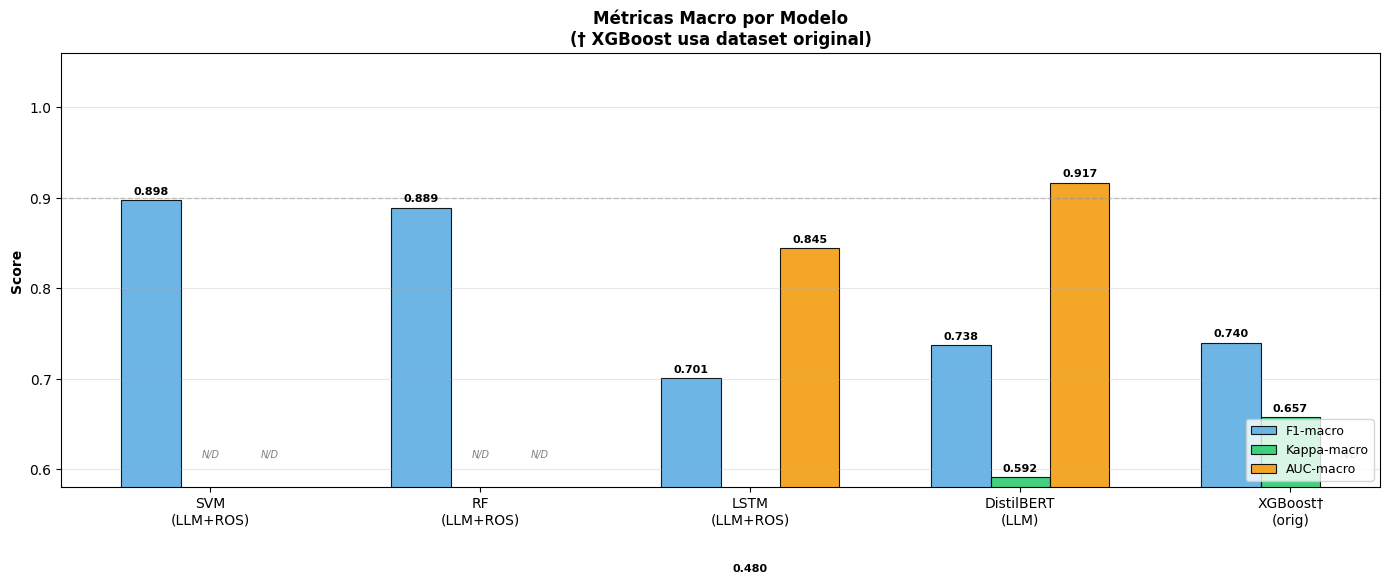

In [26]:
# =============================================================================
# GRÁFICO 1: MÉTRICAS MACRO — BARRAS AGRUPADAS
# =============================================================================

modelos   = ['SVM\n(LLM+ROS)', 'RF\n(LLM+ROS)', 'LSTM\n(LLM+ROS)', 'DistilBERT\n(LLM)', 'XGBoost†\n(orig)']
x         = np.arange(len(modelos))
width     = 0.22

f1_vals     = [f1_macro_svm_llm, f1_macro_rf_llm, f1_macro_lstm, f1_macro_distilbert, f1_macro_xgb]
kappa_vals  = [np.nan, np.nan, kappa_macro_lstm, kappa_macro_distilbert, kappa_macro_xgb]
auc_vals    = [np.nan, np.nan, auc_macro_lstm,   auc_macro_distilbert,   np.nan]

fig, ax = plt.subplots(figsize=(14, 6))

b1 = ax.bar(x - width, f1_vals,    width, label='F1-macro',    color='#5DADE2', alpha=0.9, edgecolor='black', lw=0.8)
b2 = ax.bar(x,         kappa_vals, width, label='Kappa-macro', color='#2ECC71', alpha=0.9, edgecolor='black', lw=0.8)
b3 = ax.bar(x + width, auc_vals,   width, label='AUC-macro',   color='#F39C12', alpha=0.9, edgecolor='black', lw=0.8)

for bars, vals in [(b1,f1_vals),(b2,kappa_vals),(b3,auc_vals)]:
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.004,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        else:
            ax.text(bar.get_x()+bar.get_width()/2, 0.61, 'N/D',
                    ha='center', va='bottom', fontsize=7, color='gray', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Métricas Macro por Modelo\n(† XGBoost usa dataset original)',
             fontweight='bold', fontsize=12)
ax.set_ylim([0.58, 1.06])
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, lw=1)

plt.tight_layout()
plt.savefig('../data/comparacion_metricas_macro.png', dpi=150, bbox_inches='tight')
plt.show()


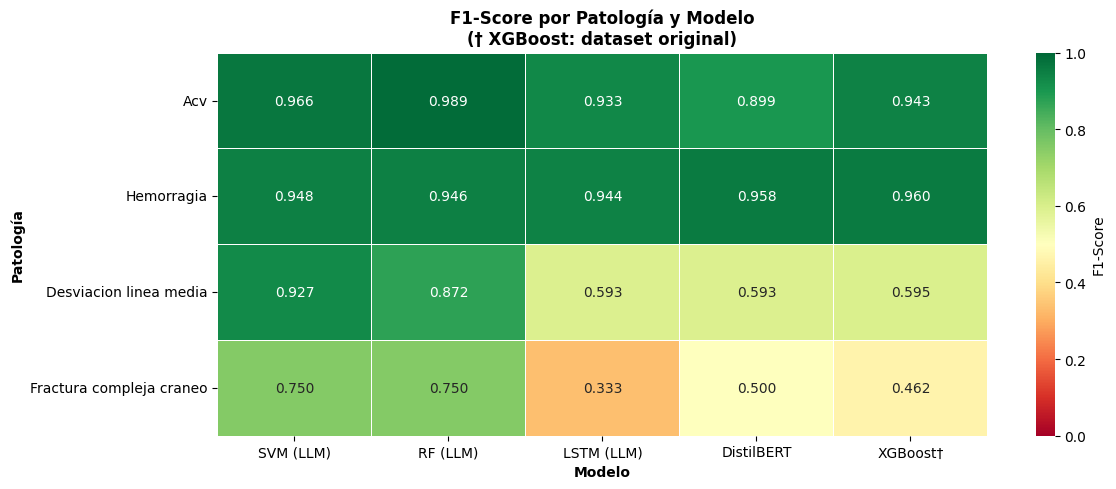

In [27]:
# =============================================================================
# GRÁFICO 2: HEATMAP F1 POR PATOLOGÍA — 5 MODELOS
# =============================================================================

df_xgb_orig = pd.DataFrame(resultados_xgb).set_index('Patología')

heatmap_data = pd.DataFrame({
    'SVM (LLM)':      [resultados_svm_llm[p]['F1']        for p in PATOLOGIAS],
    'RF (LLM)':       [resultados_rf_llm[p]['F1']         for p in PATOLOGIAS],
    'LSTM (LLM)':     [resultados_lstm_raw[p]['F1_pos']   for p in PATOLOGIAS],
    'DistilBERT':     [resultados_distilbert_raw[p]['F1_pos'] for p in PATOLOGIAS],
    'XGBoost†':       [df_xgb_orig.loc[p,'F1']            for p in PATOLOGIAS],
}, index=[p.replace('_',' ').capitalize() for p in PATOLOGIAS])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.0, vmax=1.0, ax=ax,
            cbar_kws={'label': 'F1-Score'},
            linewidths=0.5, linecolor='white')
ax.set_title('F1-Score por Patología y Modelo\n(† XGBoost: dataset original)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Modelo', fontweight='bold')
ax.set_ylabel('Patología', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/heatmap_f1_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


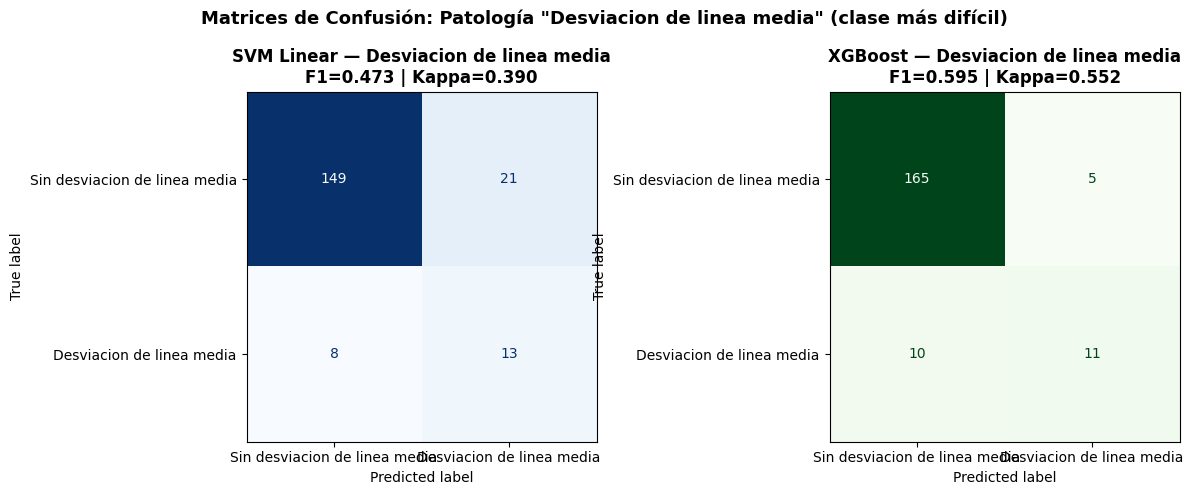


LSTM — Desviacion de linea media (valores reportados cuaderno 3):
  AUC:    0.804
  F1-Pos: 0.593
  F1-Neg: 0.905


In [28]:
# =============================================================================
# GRÁFICO 2: MATRICES DE CONFUSIÓN COMPARATIVAS (patología más crítica: desviacion de linea media)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

etiquetas_desviacion_linea_media = ['Sin desviacion de linea media', 'Desviacion de linea media']

# SVM — desviacion de linea media
cm_svm = confusion_matrix(predicciones_svm['desviacion_linea_media']['y_test'],
                           predicciones_svm['desviacion_linea_media']['y_pred'])
ConfusionMatrixDisplay(cm_svm, display_labels=etiquetas_desviacion_linea_media).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title(f'SVM Linear — Desviacion de linea media\nF1={df_svm_orig.loc["desviacion_linea_media","F1"]:.3f} | Kappa={df_svm_orig.loc["desviacion_linea_media","Kappa"]:.3f}',
                  fontweight='bold')

# XGBoost — desviacion de linea media
cm_xgb = confusion_matrix(predicciones_xgb['desviacion_linea_media']['y_test'],
                           predicciones_xgb['desviacion_linea_media']['y_pred'])
ConfusionMatrixDisplay(cm_xgb, display_labels=etiquetas_desviacion_linea_media).plot(
    ax=axes[1], cmap='Greens', colorbar=False, values_format='d')
axes[1].set_title(f'XGBoost — Desviacion de linea media\nF1={df_xgb_orig.loc["desviacion_linea_media","F1"]:.3f} | Kappa={df_xgb_orig.loc["desviacion_linea_media","Kappa"]:.3f}',
                  fontweight='bold')

plt.suptitle('Matrices de Confusión: Patología "Desviacion de linea media" (clase más difícil)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# LSTM reporte
print("\nLSTM — Desviacion de linea media (valores reportados cuaderno 3):")
print(f"  AUC:    {resultados_lstm_raw['desviacion_linea_media']['AUC']:.3f}")
print(f"  F1-Pos: {resultados_lstm_raw['desviacion_linea_media']['F1_pos']:.3f}")
print(f"  F1-Neg: {resultados_lstm_raw['desviacion_linea_media']['F1_neg']:.3f}")

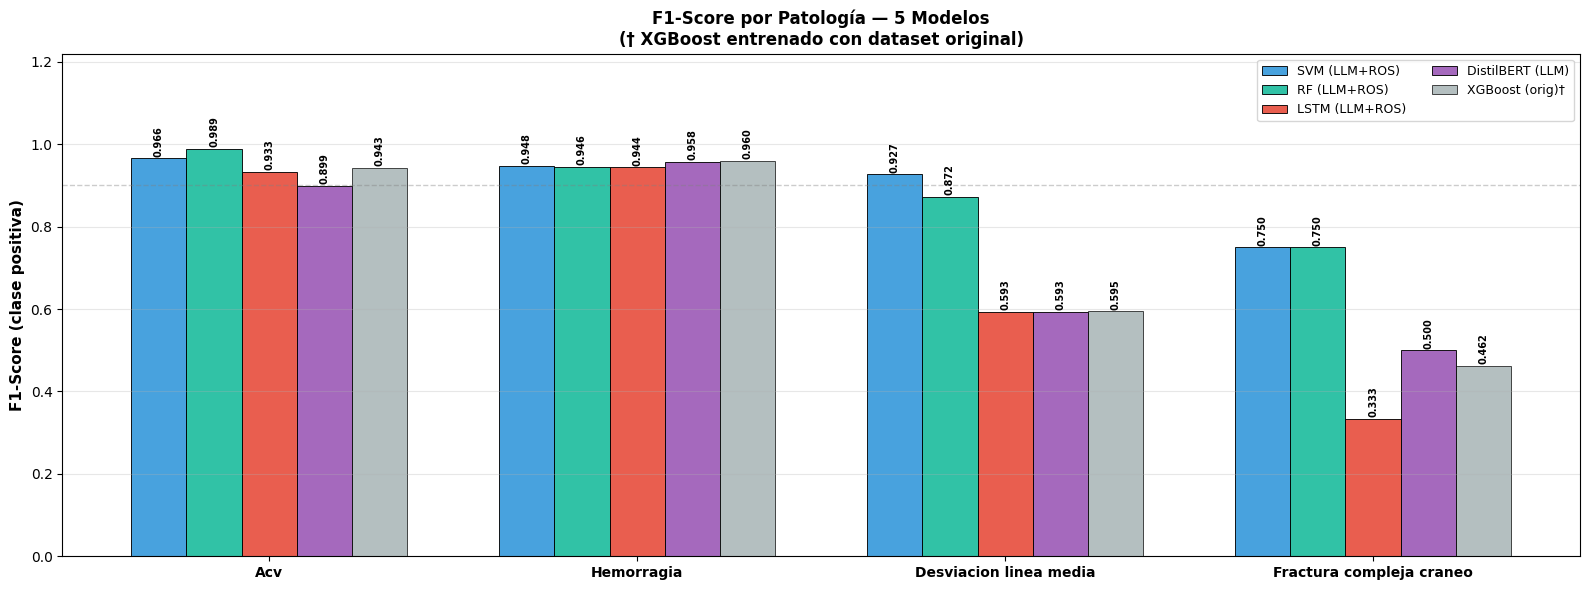

In [29]:
# =============================================================================
# GRÁFICO 3: F1 POR PATOLOGÍA — BARRAS AGRUPADAS (5 modelos)
# =============================================================================

fig, ax = plt.subplots(figsize=(16, 6))
x     = np.arange(len(PATOLOGIAS))
width = 0.15

vals_svm_llm = [resultados_svm_llm[p]['F1']      for p in PATOLOGIAS]
vals_rf_llm  = [resultados_rf_llm[p]['F1']        for p in PATOLOGIAS]
vals_lstm    = [resultados_lstm_raw[p]['F1_pos']   for p in PATOLOGIAS]
vals_dbt     = [resultados_distilbert_raw[p]['F1_pos'] for p in PATOLOGIAS]
vals_xgb     = [df_xgb_orig.loc[p,'F1']           for p in PATOLOGIAS]

b1 = ax.bar(x - 2*width, vals_svm_llm, width, label='SVM (LLM+ROS)',    color='#3498db', alpha=0.9, edgecolor='black', lw=0.7)
b2 = ax.bar(x - 1*width, vals_rf_llm,  width, label='RF (LLM+ROS)',     color='#1abc9c', alpha=0.9, edgecolor='black', lw=0.7)
b3 = ax.bar(x,            vals_lstm,   width, label='LSTM (LLM+ROS)',   color='#e74c3c', alpha=0.9, edgecolor='black', lw=0.7)
b4 = ax.bar(x + 1*width,  vals_dbt,   width, label='DistilBERT (LLM)', color='#9b59b6', alpha=0.9, edgecolor='black', lw=0.7)
b5 = ax.bar(x + 2*width,  vals_xgb,   width, label='XGBoost (orig)†', color='#95a5a6', alpha=0.7, edgecolor='black', lw=0.7)

for bars in [b1,b2,b3,b4,b5]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([p.replace('_',' ').capitalize() for p in PATOLOGIAS], fontsize=10, fontweight='bold')
ax.set_ylabel('F1-Score (clase positiva)', fontweight='bold', fontsize=11)
ax.set_title('F1-Score por Patología — 5 Modelos\n(† XGBoost entrenado con dataset original)',
             fontweight='bold', fontsize=12)
ax.set_ylim([0.0, 1.22])
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, lw=1)

plt.tight_layout()
plt.savefig('../data/comparacion_f1_por_patologia.png', dpi=150, bbox_inches='tight')
plt.show()


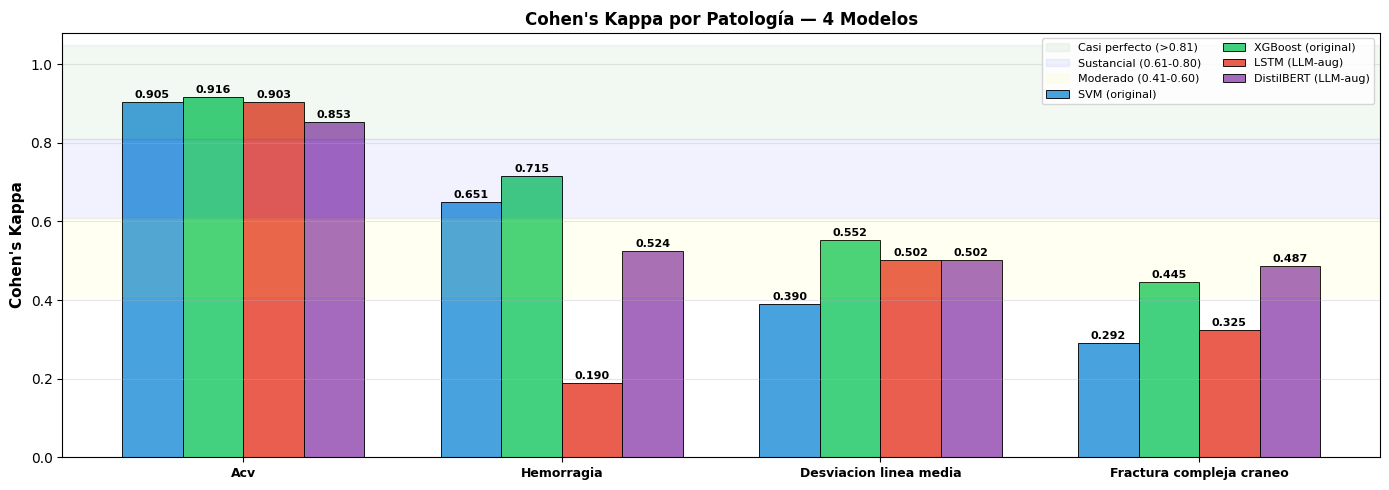

Kappa macro — SVM:        0.5591  (dataset original)
Kappa macro — XGBoost:    0.6572  (dataset original)
Kappa macro — LSTM:       0.4800  (dataset LLM-aumentado)
Kappa macro — DistilBERT: 0.5915  (dataset LLM-aumentado)


In [30]:
# =============================================================================
# GRÁFICO 4: COHEN'S KAPPA POR PATOLOGÍA (SVM, XGBoost, LSTM, DistilBERT)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

x     = np.arange(len(PATOLOGIAS))
width = 0.19

vals_k_svm  = [df_svm_orig.loc[p,'Kappa'] for p in PATOLOGIAS]
vals_k_xgb  = [df_xgb_orig.loc[p,'Kappa'] for p in PATOLOGIAS]
vals_k_lstm = [resultados_lstm_raw[p]['Kappa'] for p in PATOLOGIAS]
vals_k_dbt  = [resultados_distilbert_raw[p]['Kappa'] for p in PATOLOGIAS]

b1 = ax.bar(x - 1.5*width, vals_k_svm,  width, label='SVM (original)',   color='#3498db', alpha=0.9, edgecolor='black', lw=0.7)
b2 = ax.bar(x - 0.5*width, vals_k_xgb,  width, label='XGBoost (original)',color='#2ecc71', alpha=0.9, edgecolor='black', lw=0.7)
b3 = ax.bar(x + 0.5*width, vals_k_lstm, width, label='LSTM (LLM-aug)',   color='#e74c3c', alpha=0.9, edgecolor='black', lw=0.7)
b4 = ax.bar(x + 1.5*width, vals_k_dbt,  width, label='DistilBERT (LLM-aug)', color='#9b59b6', alpha=0.9, edgecolor='black', lw=0.7)

for bars in [b1,b2,b3,b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhspan(0.81, 1.05, alpha=0.05, color='green',  label='Casi perfecto (>0.81)')
ax.axhspan(0.61, 0.81, alpha=0.05, color='blue',   label='Sustancial (0.61-0.80)')
ax.axhspan(0.41, 0.61, alpha=0.05, color='yellow', label='Moderado (0.41-0.60)')

ax.set_xticks(x)
ax.set_xticklabels([p.replace('_',' ').capitalize() for p in PATOLOGIAS], fontsize=9, fontweight='bold')
ax.set_ylabel("Cohen's Kappa", fontweight='bold', fontsize=11)
ax.set_title("Cohen's Kappa por Patología — 4 Modelos",fontweight='bold', fontsize=12)
ax.set_ylim([0.0, 1.08])
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/comparacion_kappa.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Kappa macro — SVM:        {kappa_macro_svm:.4f}  (dataset original)")
print(f"Kappa macro — XGBoost:    {kappa_macro_xgb:.4f}  (dataset original)")
print(f"Kappa macro — LSTM:       {kappa_macro_lstm:.4f}  (dataset LLM-aumentado)")
print(f"Kappa macro — DistilBERT: {kappa_macro_distilbert:.4f}  (dataset LLM-aumentado)")

## 9. Conclusiones finales

### Resumen de rendimiento (dataset LLM-aumentado, test = 143 reales)

| Modelo | F1-macro | Kappa-macro | AUC-macro |
|---|---|---|---|
| **SVM Linear** | **0.898** | N/D | N/D |
| **Random Forest** | **0.889** | N/D | N/D |
| LSTM Bidireccional | 0.701 | 0.480 | 0.845 |
| **DistilBERT Multilingual** | 0.737 | **0.591** | **0.917** |

*XGBoost (dataset original): F1-macro=0.740, Kappa=0.657 — referencia base.*

### Análisis por patología

- **ACV:** Random Forest lidera (F1=0.989), seguido de SVM (0.966) y LSTM (0.933)
- **Hemorragia:** DistilBERT lidera en F1-pos (0.958); todos los modelos fallan en detectar los 17 negativos (clase dominante en test)
- **Desviación línea media:** SVM es el mejor (0.927) — el TF-IDF captura bien las keywords de esta patología
- **Fractura compleja:** SVM y RF empatan (0.750); DistilBERT llega a 0.500 — 5 casos en test hacen la métrica inestable para todos

### Recomendación final

>  **SVM Linear con LLM+ROS** como modelo de producción: mejor F1-macro (0.898), simple, rápido de re-entrenar y sin GPU.
> 
>  **DistilBERT** como modelo complementario: mejor Kappa (0.591) y AUC (0.917) — útil cuando se requiere calibración probabilística.
> 
>  **Fractura compleja** sigue siendo la limitación principal del sistema: solo 5 casos en test. Limitación del dataset, no del método.
